# Large Language Models: Core Principles

This notebook builds step-by-step intuition for how large language models (LLMs) process and generate text. We use the German *Grundgesetz* (Basic Law) as a concrete corpus. We will:
- Load the PDF and extract its text
- Visualize character frequency distributions
- Build an n-gram model to predict and generate new text
- Explore why neural networks are needed beyond simple n-grams
- Understand how modern LLMs tokenize text using subword encodings

## 1. Import Required Libraries

We will use libraries for PDF reading and text processing.

In [2]:
# Import required libraries
from PyPDF2 import PdfReader
import pandas as pd
import random
import tiktoken
import matplotlib.pyplot as plt
from IPython.display import display, HTML
from collections import defaultdict, Counter

## 2. Load and Read PDF Document

We will load the document and extract its text for analysis.

In [3]:
# Load and read the PDF document
pdf_path = 'Grundgesetz.pdf'
text = ''
with open(pdf_path, 'rb') as file:
    reader = PdfReader(file)
    for page in reader.pages:
        text += page.extract_text()

## 3. Preview Extracted Text

Let's inspect a passage from the extracted text to confirm the extraction worked correctly.

In [4]:
# Preview a passage from the text to confirm the extraction worked
# The index range [2886:3420] corresponds to Article 3 (Equality before the law)
print(text[2886:3420])


Art 3  
(1) Alle Menschen sind vor dem Gesetz gleich.
(2) Männer und Frauen sind gleichberechtigt. Der Staat fördert die tatsächliche Durchsetzung der
Gleichberechtigung von Frauen und Männern und wirkt auf die Beseitigung bestehender Nachteile hin.
(3) Niemand darf wegen seines Geschlechtes, seiner Abstammung, seiner Rasse, seiner Sprache, seiner Heimat
und Herkunft, seines Glaubens, seiner religiösen oder politischen Anschauungen benachteiligt oder bevorzugt
werden. Niemand darf wegen seiner Behinderung benachteiligt werden.



## 4. Character Frequency Analysis

Before building a generative model, let's look at the simplest statistics: how often does each character appear? Even this basic distribution already reflects the structure of the language — for example, German has a high frequency of 'e', 'n', and 'i', while 'q', 'x', and 'y' are rare.

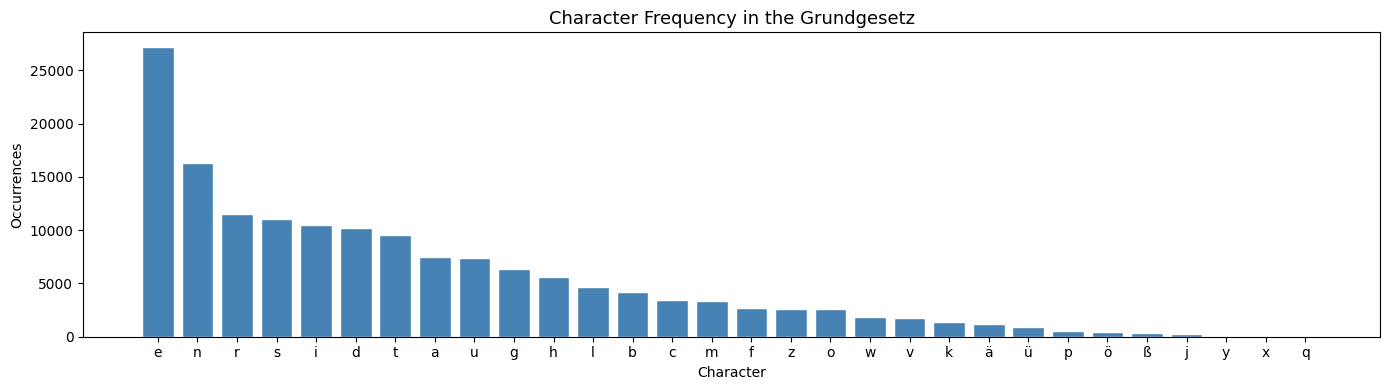

In [5]:
# Count frequency of each letter (case-insensitive, alphabetic only)
char_counts = Counter(c.lower() for c in text if c.isalpha())
chars, freqs = zip(*sorted(char_counts.items(), key=lambda x: x[1], reverse=True))

plt.figure(figsize=(14, 4))
plt.bar(chars, freqs, color='steelblue', edgecolor='white')
plt.title('Character Frequency in the Grundgesetz', fontsize=13)
plt.xlabel('Character')
plt.ylabel('Occurrences')
plt.tight_layout()
plt.show()

## 5. N-Gram Model

An **n-gram** is a sequence of *n* consecutive characters. By counting how often each n-gram appears in the text, we can build a simple probabilistic model: given the last `n-1` characters, predict the next one based on observed frequencies.

**Try it:** Change `n` in the cell below and re-run the following cells.  
- Small `n` (e.g., 2–4): very little context, output looks random  
- Large `n` (e.g., 15–25): high fidelity, but starts copying training text verbatim

In [6]:
# ─────────────────────────────────────────────────────────────────
# TODO: Change n and re-run this cell plus all cells below to see
#       how the choice affects the model's vocabulary and generation.
# ─────────────────────────────────────────────────────────────────
n = 20  # Length of n-gram (number of characters)

# Compute n-gram transition counts
ngrams = Counter()
for i in range(len(text) - n + 1):
    ngram = tuple(text[i:i+n])
    ngrams[ngram] += 1

# Show the top 50 most frequent n-grams
top_ngrams = sorted(ngrams.items(), key=lambda x: x[1], reverse=True)
top_df = pd.DataFrame([(str(seq), count) for seq, count in top_ngrams[:50]], columns=['Sequence', 'Count'])

# Display side by side in chunks of 20
chunk_size = 20
html_parts = [top_df.iloc[i:i+chunk_size].to_html(index=False) for i in range(0, len(top_df), chunk_size)]
html = '<table style="border-collapse: collapse;"><tr>'
for part in html_parts:
    html += f'<td style="vertical-align: top; padding: 10px;">{part}</td>'
html += '</tr></table>'

print(f"n = {n}  |  Total unique n-grams: {len(ngrams)}")
display(HTML(html))

n = 20  |  Total unique n-grams: 162624


Sequence,Count
"('Z', 'u', 's', 't', 'i', 'm', 'm', 'u', 'n', 'g', ' ', 'd', 'e', 's', ' ', 'B', 'u', 'n', 'd', 'e')",86
"('u', 's', 't', 'i', 'm', 'm', 'u', 'n', 'g', ' ', 'd', 'e', 's', ' ', 'B', 'u', 'n', 'd', 'e', 's')",86
"('s', 't', 'i', 'm', 'm', 'u', 'n', 'g', ' ', 'd', 'e', 's', ' ', 'B', 'u', 'n', 'd', 'e', 's', 'r')",82
"('t', 'i', 'm', 'm', 'u', 'n', 'g', ' ', 'd', 'e', 's', ' ', 'B', 'u', 'n', 'd', 'e', 's', 'r', 'a')",82
"('i', 'm', 'm', 'u', 'n', 'g', ' ', 'd', 'e', 's', ' ', 'B', 'u', 'n', 'd', 'e', 's', 'r', 'a', 't')",82
"('m', 'm', 'u', 'n', 'g', ' ', 'd', 'e', 's', ' ', 'B', 'u', 'n', 'd', 'e', 's', 'r', 'a', 't', 'e')",82
"('m', 'u', 'n', 'g', ' ', 'd', 'e', 's', ' ', 'B', 'u', 'n', 'd', 'e', 's', 'r', 'a', 't', 'e', 's')",82
"(' ', 'Z', 'u', 's', 't', 'i', 'm', 'm', 'u', 'n', 'g', ' ', 'd', 'e', 's', ' ', 'B', 'u', 'n', 'd')",81
"('u', 'n', 'g', ' ', 'd', 'e', 's', ' ', 'B', 'u', 'n', 'd', 'e', 's', 'r', 'a', 't', 'e', 's', ' ')",60
"('E', 'i', 'n', ' ', 'S', 'e', 'r', 'v', 'i', 'c', 'e', ' ', 'd', 'e', 's', ' ', 'B', 'u', 'n', 'd')",51


## 6. Text Generation from N-Grams

We build a **Markov chain** over the n-grams: given the last `n-1` characters of the current output, the next character is randomly sampled from all observed continuations, weighted by their frequency in the training text.

In [7]:
# Build the Markov chain: for every (n-1)-gram prefix, record how often each next character follows
model = defaultdict(Counter)
for ngram, count in ngrams.items():
    prefix = ngram[:-1]
    next_char = ngram[-1]
    model[prefix][next_char] = count


def generate_text(start, length):
    current = list(start)
    for _ in range(length):
        prefix = tuple(current[-(n-1):])
        if prefix in model and model[prefix]:
            chars, counts = zip(*model[prefix].items())
            next_char = random.choices(chars, weights=counts, k=1)[0]
            current.append(next_char)
        else:
            break  # Stop if no continuation found for this prefix
    return ''.join(current)


# Generate text starting from a seed sequence
start_sequence = 'Alle Menschen sind vor dem'
generated_text = generate_text(start_sequence, 500)
print("Generated text:\n")
print(generated_text)

# TODO: Try different starting sequences. What happens if the seed is not
#       present verbatim in the training text? Does the output still make sense?

Generated text:

Alle Menschen sind vor dem Gesetz gleich.
(2) Männer und Frauen sind gleichberechtigt. Der Staat fördert die tatsächliche Durchsetzung der
Gleichberechtigung von Frauen und Männern und wirkt auf die Beseitigung bestehender Nachteile hin.
(3) Niemand darf gegen sein Gewissen zum Kriegsdienst mit der Waffe gezwungen werden. Das Nähere regelt ein Bundesgesetz, das der Zustimmung des Bundesrates erforderlich ist. Bis zum Erlaß eines solchen Gesetzes kann das Bundesverfassungsgericht mit der Mehrheit der Stimmen des Bundesrat


## 7. The Context Window and its Limits

The length of the context window (`n-1` characters) is the central parameter of any n-gram model:

- It controls the **coherence and topic** of the generated text
- As `n` grows, the number of distinct n-grams grows exponentially — most are seen only once or twice in the training data (**data sparsity problem**)
- With very large `n`, the model essentially copies verbatim passages from the training text rather than generalizing

This is the key motivation for a **neural network**: instead of storing all observed n-grams as a lookup table, a network *learns to estimate* the probability of the next token from a compact, continuous representation of the context.

**Exercise:** Run the cell below to compare text generated with different values of `n` on a text excerpt. At which `n` does the output transition from incoherent to copied?

In [8]:
# Compare text generation quality for different values of n
# Uses the first 20,000 characters so each run stays fast

text_subset = text[:20_000]
seed = 'Alle Menschen sind v'

for n_test in [3, 7, 15]:
    # Build n-gram counts
    ng = Counter()
    for i in range(len(text_subset) - n_test + 1):
        ng[tuple(text_subset[i:i+n_test])] += 1

    # Build Markov model
    m = defaultdict(Counter)
    for ngram, count in ng.items():
        m[ngram[:-1]][ngram[-1]] = count

    # Generate from seed (trim to n_test-1 chars)
    current = list(seed[:n_test - 1])
    for _ in range(200):
        prefix = tuple(current[-(n_test - 1):])
        if prefix in m and m[prefix]:
            chars, counts = zip(*m[prefix].items())
            current.append(random.choices(chars, weights=counts, k=1)[0])
        else:
            break

    print(f"─── n = {n_test} ───")
    print(''.join(current))
    print()

─── n = 3 ───
Allgem Es und Ersowirden inesetzehörisseten
digem Diehen untliche 4 ehtsbilden Entbist natz einertiz 1 könne Diedlander pollen Ver nang darfGE vorzunkerdnurche
Scht rin auf auch Allzoge derson dundestei

─── n = 7 ───
Alle Menschen Rat beschlossene Grund unverletzlich.
(2) Durchsetzung festgestellt ist; bei Gefahr für die öffentlichen Menschenrechten und verkündet.
Das Grund eines Gesetzes angeordnet werden; eine abweich

─── n = 15 ───
Alle Menschen sind vor dem Gesetz gleich.
(2) Männer und Frauen sind gleichberechtigtes Glied in einem vereinten Europa
dem Frieden der Welt zu dienen, hat sich das Deutsche Volk bekennt sich darum zu unverletzlich



## 8. Tokens

Character-level n-grams are a useful thought experiment, but real LLMs do not work on individual characters:

- Encoding single characters leads to very **long sequences**, making it hard for a network to learn long-range dependencies
- Individual characters carry very **little semantic information**

Modern LLMs use a **tokenizer** to split text into *tokens* — subword units that sit between individual characters and full words. Each unique token is assigned an integer ID, so the model learns to predict a sequence of integers.

The GPT family uses **Byte-Pair Encoding (BPE)**: the most frequent character pairs in the training corpus are iteratively merged until a fixed vocabulary size is reached. Common words become single tokens; rare or compound words are split into smaller pieces.

In [9]:
# Get the tokenizer for the GPT-4o model
enc = tiktoken.encoding_for_model("gpt-4o")

# Encode a string into tokens
tokens = enc.encode("Art 3  \
(1) Alle Menschen sind vor dem Gesetz gleich. \
(2) Männer und Frauen sind gleichberechtigt. Der Staat fördert die tatsächliche Durchsetzung der \
Gleichberechtigung von Frauen und Männern und wirkt auf die Beseitigung bestehender Nachteile hin. \
(3) Niemand darf wegen seines Geschlechtes, seiner Abstammung, seiner Rasse, seiner Sprache, seiner Heimat \
und Herkunft, seines Glaubens, seiner religiösen oder politischen Anschauungen benachteiligt oder bevorzugt \
werden. Niemand darf wegen seiner Behinderung benachteiligt werden.")
print(tokens) 

[8372, 220, 18, 220, 350, 16, 8, 22665, 19488, 5029, 5774, 2019, 81754, 26315, 13, 350, 17, 8, 55639, 844, 36087, 5029, 26315, 16907, 152877, 13, 8296, 62887, 6731, 66454, 1076, 193375, 9617, 32002, 59278, 1227, 76717, 16907, 3487, 28493, 2812, 36087, 844, 172787, 844, 94781, 2933, 1076, 418, 1220, 278, 28493, 96409, 1644, 186616, 14508, 13, 350, 18, 8, 194728, 48469, 41383, 83911, 16341, 44367, 2822, 11, 26438, 127025, 5518, 988, 11, 26438, 460, 5788, 11, 26438, 89476, 11, 26438, 108297, 844, 141729, 11, 83911, 123418, 696, 11, 26438, 134340, 74050, 5126, 134282, 73307, 753, 4644, 2974, 678, 23405, 6591, 5126, 146180, 83, 5285, 13, 194728, 48469, 41383, 26438, 25348, 156491, 2974, 678, 23405, 6591, 5285, 13]


In [11]:
import colorsys

# Display each token as a color-coded block so you can see where word boundaries fall
def token_color(idx):
    hue = (idx * 0.618033988749895) % 1.0  # golden-ratio hue spacing avoids adjacent colors
    r, g, b = colorsys.hsv_to_rgb(hue, 0.50, 0.93)
    return f'#{int(r*255):02x}{int(g*255):02x}{int(b*255):02x}'

html_tokens = ''
for i, token in enumerate(tokens):
    word = enc.decode_single_token_bytes(token).decode('utf-8', errors='replace')
    color = token_color(i)
    html_tokens += (
        f'<span style="background:{color}; color:#000000; padding:3px 5px; margin:2px; '
        f'border-radius:4px; font-family:monospace; font-size:14px;">{word}</span>'
    )

display(HTML(f'<div style="line-height:2.6;">{html_tokens}</div>'))
print(f"\nTotal tokens: {len(tokens)}  |  GPT-4o vocabulary size: {enc.n_vocab:,}")

# TODO: Try encoding a German compound word (e.g., "Grundgesetzmäßigkeit") or
#       a word from a different language. How many tokens does it require?


Total tokens: 118  |  GPT-4o vocabulary size: 200,019


## Summary

This notebook walked through the core ideas behind language modeling:

| Step | Method | Key limitation |
|------|--------|----------------|
| Character statistics | Unigram frequency histogram | No sequential structure |
| N-gram model | Markov chain over character sequences | Data sparsity; copies training text at large *n* |
| Context window | Last *n−1* characters predict next | Exponential state growth |
| Neural network | Learned probability estimator | *(covered in later sessions)* |
| Tokenization | Subword BPE encoding | Vocabulary is language-dependent |

### Reflection Questions

1. What happens to the number of unique n-grams as you increase `n`? Why is this a problem for a lookup-table approach?
2. At what value of `n` does generated text transition from incoherent to copied verbatim? Why?
3. Why do LLMs use tokens (subword units) instead of individual characters or full words?
4. How does the choice of training corpus influence what a language model "knows" and what kinds of text it generates?